# Calibration & validation

This notebook documents how the analysis method was developed: how the hive position was derived, how the distance tolerance `TOL` was chosen, why we moved from a naive first-sample exit classifier (v1) to a velocity-back-extrapolation one (v2), and why both were ultimately fused into a hybrid (v3). It also includes a multi-day stability sweep you can run periodically to check that `re_ratio` isn't drifting over time.

**You don't need to run this every time you analyse a new day's detections.** That's the job of `components.ipynb`. Run this notebook when:

- You want to understand why the pipeline is wired the way it is.
- You added a new camera (re-run *Hive-position calibration* to derive its hive position).
- You're unsure the classifier is still behaving correctly (re-run *Multi-day validation sweep*).
- You want to inspect a specific flight track, or debug a day-count mismatch between the notebook and the PATS web UI.

## Sections

1. **Debug: inspect one specific detection.** Pull a flight track up by timestamp and see exactly which XYZ samples drove its classification.
2. **Detection-distribution check.** Sanity-check that the notebook's date count matches PATS' web UI. Catches timezone mismatches.
3. **Hive-position calibration.** Where is the hive, in each camera's local coordinate frame? Uses the 3D mode of final XYZ samples - bees always end up at the hive, so the mode of last positions *is* the hive. Run once per camera.
4. **TOL threshold diagnostic.** Histograms of `min_dist_hive` (drives returns) and `min_dist_start` (drives v1 exits) with reference tolerance lines and a CDF. The return side is cleanly bimodal, which is why a simple distance threshold works for returns. The exit side is *not* bimodal, which is why v1 alone is unreliable and motivated v2 / v3.
5. **v1-vs-v2 disagreement viewer.** Three 3D sub-plots showing the tracks each classifier flags but the other one doesn't. Documents visually why neither is sufficient alone.
6. **Multi-day validation sweep.** For every `(date, system_id)` folder in `cache/`, runs all three classifiers and plots `re_ratio` across days. v3 should hug 1.0; v1 and v2 should swing. This is the section to re-run periodically.

## How to read the results

- **`re_ratio = n_returns / n_exits`.** Target is 1.0 (every bee that leaves comes back). Above 1 = we're missing exits. Below 1 = we're missing returns or inventing exits.
- **Stability matters more than absolute value.** If re_ratio wobbles between 0.6 and 2.3 day-to-day, the classifier is unreliable even if individual days look OK. A stable re_ratio slightly off 1.0 is better than a wildly swinging one that averages to 1.0.
- **`night_count = 0`** should always hold. Bumblebees don't fly in the dark. Non-zero values point at timezone parsing issues or noise.

## Prerequisites

Most cells reference variables built by `components.ipynb` (`detections`, `flight_tracks` / `ft_v2`, `exit_results` and `exit_results_v1` and `exit_results_v2`, `results`, `HIVE_BY_SYSTEM`, `TOL`, `EXPORT_DIR`, etc.). **Run `components.ipynb` top-to-bottom first in the same Jupyter kernel**, then open and run cells in this notebook. The *Multi-day validation sweep* (section 6) is the exception - it reads from `cache/` directly and is fully self-contained.


### 1. Debug: inspect one specific detection

Useful when you know a flight *should* count as a hive return (e.g. you watched the video) but the notebook says it doesn't. Enter the detection's timestamp and we'll print:
- which row of `detections` it matches (so you get the `uid` + `system_id`)
- the tail of that flight track (so you see the raw last samples)
- the last valid `(x, y, z)` and its distance from the hive

If the last point looks way off the hive coordinates you typed in, the likely culprits are:
1. **Each camera has its own local coordinate frame.** `system=900` and `system=939` don't share axes. Hive coords pulled from a `system=900` video won't apply to a `system=939` track.
2. The axis you think is "up" may be one of the others — PATS-C uses +x right, +y down, +z forward from the camera.
3. The per-axis tolerance of 0.1 m is a box, not a sphere. A flight that stops 0.15 m away in just one axis won't count.


In [18]:
# --- Pick a detection by its timestamp (format: YYYYmmdd_HHMMSS) -------------
TARGET_DT_STR = "20260419_125330"
# ---------------------------------------------------------------------------

# detections['datetime'] is either a full datetime or the start_datetime string.
# We'll search both columns to be safe.
candidates = detections.copy()
mask = False
for col in ("datetime", "start_datetime"):
    if col in candidates.columns:
        col_str = candidates[col].astype(str)
        mask = mask | col_str.str.contains(TARGET_DT_STR, na=False)
hits = candidates[mask] if hasattr(mask, "any") else pd.DataFrame()

if hits.empty:
    # Fall back: parse the timestamp and look for detections within +/- 1 minute.
    t0 = pd.to_datetime(TARGET_DT_STR, format="%Y%m%d_%H%M%S")
    for col in ("datetime", "start_datetime"):
        if col in detections.columns:
            parsed = pd.to_datetime(detections[col], errors="coerce", utc=True).dt.tz_localize(None)
            hits = detections[(parsed - t0).abs() < pd.Timedelta("1min")]
            if not hits.empty:
                break

print(f"{len(hits)} detection(s) matching {TARGET_DT_STR}:")
display_cols = [c for c in ("uid","datetime","start_datetime","system_id","row_id","post_id","duration") if c in hits.columns]
hits[display_cols] if not hits.empty else hits


0 detection(s) matching 20260419_125330:


/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1132905071.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(detections[col], errors="coerce", utc=True).dt.tz_localize(None)


,datetime,dist_traject,dist_traveled,duration,light_level,post_id,row_id,size,start_datetime,uid,vel_max,vel_mean,vel_std,system_id


In [19]:
# For each matching detection, show the tail of the track and the last valid xyz.
import numpy as np

for _, row in hits.iterrows():
    uid = int(row["uid"])
    print("=" * 70)
    print(f"uid={uid}  system_id={row.get('system_id')}  row={row.get('row_id')}  post={row.get('post_id')}")

    trk = tracks.get(uid)
    if trk is None:
        # Not in memory? try the cache, or pull fresh.
        track_path = TRACKS_DIR / f"{uid}.csv"
        if track_path.exists():
            trk = pd.read_csv(track_path)
        else:
            trk = service.download_c_flight_track(section_id, uid)
            trk.to_csv(track_path, index=False)

    print(f"  total frames: {len(trk)}")
    if "pos_valid_insect" in trk.columns:
        valid = trk[trk["pos_valid_insect"] == 1]
        print(f"  frames with pos_valid_insect==1: {len(valid)}")
    else:
        valid = trk

    cols = [c for c in ("elapsed","posX_insect","posY_insect","posZ_insect","pos_valid_insect") if c in trk.columns]
    print("  last 5 rows of the full track:")
    print(trk[cols].tail().to_string(index=False))

    if not valid.empty:
        last = valid.iloc[-1]
        xyz = np.array([last["posX_insect"], last["posY_insect"], last["posZ_insect"]], dtype=float)
        delta = xyz - HIVE_POS
        print(f"  last valid (x,y,z) = ({xyz[0]:.4f}, {xyz[1]:.4f}, {xyz[2]:.4f})")
        print(f"  delta to hive      = ({delta[0]:+.4f}, {delta[1]:+.4f}, {delta[2]:+.4f})")
        print(f"  |delta| euclid     = {np.linalg.norm(delta):.4f} m")
        per_axis_ok = np.abs(delta) <= TOL
        print(f"  within tol (±{TOL} per axis)? x={per_axis_ok[0]}, y={per_axis_ok[1]}, z={per_axis_ok[2]}")
    else:
        print("  (no valid positions in this track)")


In [20]:
trk = tracks[1332812]                                # DataFrame of all frames
trk[["posX_insect","posY_insect","posZ_insect"]].tail()    # last 5 points

# just the last valid point
valid = trk[trk["pos_valid_insect"] == 1]
valid[["posX_insect","posY_insect","posZ_insect"]].iloc[-1]

KeyError: 1332812

In [55]:
trk = tracks[1332812]
trk[["elapsed","posX_insect","posY_insect","posZ_insect","pos_valid_insect"]].tail(10)

,elapsed,posX_insect,posY_insect,posZ_insect,pos_valid_insect
107,2566.301213,-0.023402,-0.620459,-1.19226,1
108,2566.312340,-0.022016,-0.616939,-1.19213,1
109,2566.323469,-0.020631,-0.613421,-1.19199,1
110,2566.334597,-0.019246,-0.609903,-1.19186,1
111,2566.345725,-0.017862,-0.606387,-1.19172,1
112,2566.356853,-0.016478,-0.602872,-1.19159,1
113,2566.367981,-0.015094,-0.599358,-1.19145,1
114,2566.379109,-0.013711,-0.595846,-1.19132,1
115,2566.390238,-0.013711,-0.595846,-1.19132,1
116,2566.401365,-0.013711,-0.595846,-1.19132,1


### 2. Detection-distribution check (timezone / count sanity)

Notebook count vs. web-UI count disagreeing is almost always a timezone mismatch. This cell:

1. Counts `detections` by their **local-date prefix** (from the `datetime` column, which PATS returns in Europe/Amsterdam local time).
2. Also counts by **UTC date** (parsed from `start_datetime`, which is GMT).
3. Prints the earliest and latest detection in each.

If the local-date column says "April 22: 387, April 21: 272" when `TARGET_DATE = 2026-04-22`, your query window is leaking into April 21 and the fix is to shift the `day_start` / `day_end` by the Amsterdam UTC offset (+2 h in April).


In [32]:
import pandas as pd

print(f"TARGET_DATE   = {TARGET_DATE.date()}")
print(f"Total rows    = {len(detections)}")
print()

# 1. Local-date distribution (what the PATS web UI groups by).
local_date = detections["datetime"].astype(str).str[:8]           # YYYYMMDD
print("By LOCAL date (Europe/Amsterdam, from `datetime` column):")
print(local_date.value_counts().sort_index().to_string())
print()

# 2. UTC-date distribution (what the server likely groups by internally).
utc_dt = pd.to_datetime(detections["start_datetime"], errors="coerce", utc=True)
utc_date = utc_dt.dt.strftime("%Y%m%d")
print("By UTC date (from `start_datetime`):")
print(utc_date.value_counts().sort_index().to_string())
print()

# 3. Earliest / latest in each frame of reference.
print("Earliest / latest `datetime`      (local):",
      detections["datetime"].min(), "->", detections["datetime"].max())
print("Earliest / latest `start_datetime`(UTC)  :",
      utc_dt.min(), "->", utc_dt.max())


TARGET_DATE   = 2026-04-21
Total rows    = 603

By LOCAL date (Europe/Amsterdam, from `datetime` column):
datetime
20260421    603

By UTC date (from `start_datetime`):
start_datetime
20260421    603

Earliest / latest `datetime`      (local): 20260421_071942 -> 20260421_185228
Earliest / latest `start_datetime`(UTC)  : 2026-04-21 05:19:42+00:00 -> 2026-04-21 16:52:28+00:00


### 3. Hive-position calibration

Sanity check on `hive_900_pos` / `hive_939_pos`: take the last valid XYZ of every track (and optionally the first, since exits depart from the hive too), bin into small 3D cubes, and take the most-populated cube. Works per `system_id` because each camera has its own coordinate frame.

- **BUCKET** - cube size in metres. 5 cm is a good default.
- **USE_FIRST** - include first valid XYZ of each track as well as the last. Doubles the support.
- **TOP_K** - how many top buckets to print.
- **REFINE_RADIUS** - weighted centroid is computed over all points within this radius of the winning bucket centre, for sub-bucket precision.

The printed "refined centroid" is the empirical hive position. Compare to the configured `hive_900_pos` / `hive_939_pos` - the delta tells you how far off your manual calibration is.



=== system_id=900  (n samples = 1692) ===
configured  hive_900_pos = (-0.040, -0.665, -1.195)
top 5 buckets (centre x, y, z  -  count):
  (-0.050, -0.650, -1.150)   69
  (-0.050, -0.650, -1.200)   43
  (+0.000, -0.650, -1.150)   29
  (+0.000, -0.650, -1.200)   20
  (+0.000, -0.600, -1.150)   11
refined centroid (n=219 within 10 cm): (-0.037, -0.647, -1.167)
delta vs configured: (+0.003, +0.018, +0.028)  |3.4 cm|


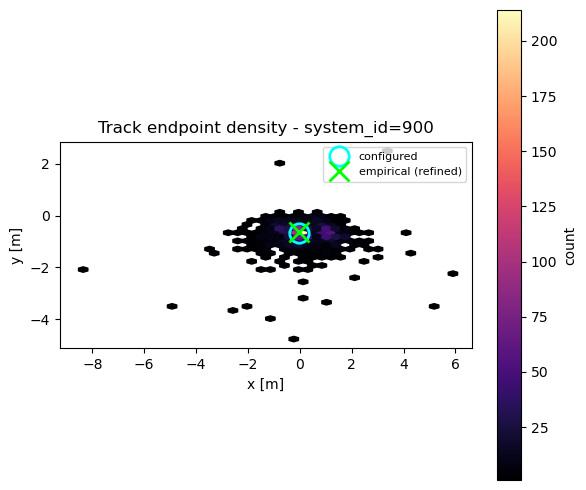

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

# -- Controls ---------------------------------------------------------------
BUCKET         = 0.05   # 5 cm grid
USE_FIRST      = True   # include first valid XYZ too (exits start at hive)
TOP_K          = 5
REFINE_RADIUS  = 0.10   # 10 cm
# ---------------------------------------------------------------------------

# 1. Load tracks.
ft = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft.columns:
    ft = ft[ft["pos_valid_insect"] == 1]

# 2. Make sure we have a system_id column. flight_tracks.csv already has one;
#    fall back to detections if needed.
if "system_id" not in ft.columns:
    _sys = detections[["uid", "system_id"]].drop_duplicates("uid")
    ft = ft.merge(_sys, left_on="detection_uid", right_on="uid", how="left")
ft = ft.dropna(subset=["system_id"])
ft["system_id"] = ft["system_id"].astype(int)

# 3. Sort so .head(1) / .tail(1) is temporally meaningful.
sort_cols = ["detection_uid"]
for cand in ("rs_id", "time_insect", "timestamp"):
    if cand in ft.columns:
        sort_cols.append(cand)
        break
ft = ft.sort_values(sort_cols)

configured = {900: hive_900_pos, 939: hive_939_pos}

for sys_id, g in ft.groupby("system_id"):
    g_uid = g.groupby("detection_uid")
    last  = g_uid.tail(1)
    pts   = last[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy()
    if USE_FIRST:
        first = g_uid.head(1)
        pts = np.vstack([
            pts,
            first[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(),
        ])

    # 4. Bucket into the 3D grid.
    buckets = np.round(pts / BUCKET).astype(int)
    counter = Counter(map(tuple, buckets))
    top = counter.most_common(TOP_K)

    print(f"\n=== system_id={sys_id}  (n samples = {len(pts)}) ===")
    if int(sys_id) in configured:
        cfg = configured[int(sys_id)]
        print(f"configured  hive_{sys_id}_pos = "
              f"({cfg[0]:+.3f}, {cfg[1]:+.3f}, {cfg[2]:+.3f})")
    else:
        cfg = None
        print(f"(no configured hive for system_id={sys_id})")
    print(f"top {TOP_K} buckets (centre x, y, z  -  count):")
    for (bx, by, bz), n in top:
        cx, cy, cz = bx * BUCKET, by * BUCKET, bz * BUCKET
        print(f"  ({cx:+.3f}, {cy:+.3f}, {cz:+.3f})   {n}")

    # 5. Refined centroid within REFINE_RADIUS of the winner.
    bx, by, bz = top[0][0]
    winner = np.array([bx * BUCKET, by * BUCKET, bz * BUCKET])
    d = np.linalg.norm(pts - winner, axis=1)
    near = pts[d <= REFINE_RADIUS]
    centroid = near.mean(axis=0)
    print(f"refined centroid (n={len(near)} within {REFINE_RADIUS*100:.0f} cm): "
          f"({centroid[0]:+.3f}, {centroid[1]:+.3f}, {centroid[2]:+.3f})")

    if cfg is not None:
        delta = centroid - np.asarray(cfg)
        print(f"delta vs configured: "
              f"({delta[0]:+.3f}, {delta[1]:+.3f}, {delta[2]:+.3f})  "
              f"|{np.linalg.norm(delta)*100:.1f} cm|")

    # 6. Visual: top-down (x, y) heatmap of endpoints.
    fig, ax = plt.subplots(figsize=(6, 5))
    h = ax.hexbin(pts[:, 0], pts[:, 1], gridsize=40, cmap="magma", mincnt=1)
    if cfg is not None:
        ax.plot(cfg[0], cfg[1],
                "o", markersize=14, markerfacecolor="none",
                markeredgecolor="cyan", markeredgewidth=2, label="configured")
    ax.plot(centroid[0], centroid[1],
            "x", markersize=14, markeredgecolor="lime", markeredgewidth=2,
            label="empirical (refined)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    ax.set_title(f"Track endpoint density - system_id={sys_id}")
    ax.legend(loc="best", fontsize=8)
    fig.colorbar(h, ax=ax, label="count")
    plt.tight_layout()
    plt.show()


### 4. TOL threshold diagnostic

Histogram + CDF of the two distances that drive classification:
- **`min_dist_hive`** from `results` - closest the track ever got to the hive during its tail frames. Drives `hive_return`.
- **`min_dist_start`** from `exit_results` - distance of the first valid sample from the hive. Drives `hive_exit`.

**What to look for.** If the distribution has a sharp spike near zero (real events) with a long flat tail (fly-bys) and a clear valley between them, pick TOL at the valley - that's a principled threshold. If it decays monotonically with no valley, min-distance alone can't separate events from fly-bys and we need a second feature (e.g. inward-velocity direction at track end).

The CDF on the right-hand y-axis lets you read off "if TOL=X, I catch Y% of tracks" directly.


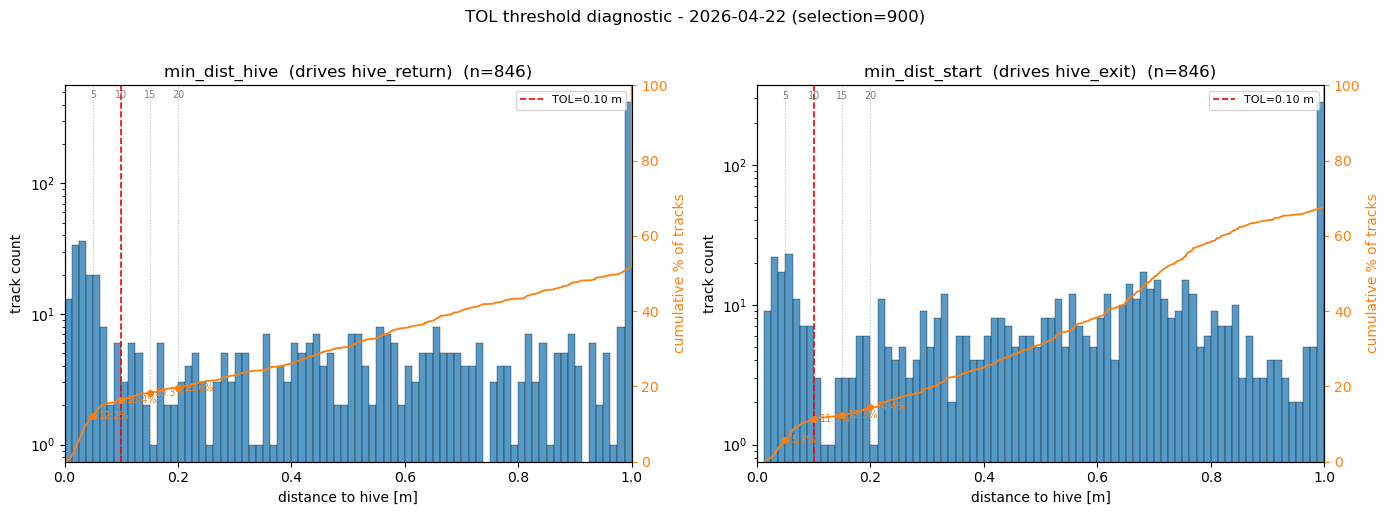


min_dist_hive  (n=846)
  TOL=0.05 m  ->    103 tracks ( 12.2%)
  TOL=0.10 m  ->    139 tracks ( 16.4%)
  TOL=0.15 m  ->    155 tracks ( 18.3%)
  TOL=0.20 m  ->    166 tracks ( 19.6%)

min_dist_start  (n=846)
  TOL=0.05 m  ->     48 tracks (  5.7%)
  TOL=0.10 m  ->     96 tracks ( 11.3%)
  TOL=0.15 m  ->    104 tracks ( 12.3%)
  TOL=0.20 m  ->    122 tracks ( 14.4%)


In [27]:
import matplotlib.pyplot as plt

# -- Controls --------------------------------------------------------------
XMAX        = 1.0          # m, histogram x-axis clip
N_BINS      = 80
LOG_Y       = True         # log y-axis on the histograms
REF_TOLS    = [0.05, 0.10, 0.15, 0.20]   # grey gridlines
# -------------------------------------------------------------------------

def _panel(ax, series, title, current_tol):
    vals = series.dropna().clip(upper=XMAX).to_numpy()
    if len(vals) == 0:
        ax.set_title(f"{title} (no data)")
        return

    bins = np.linspace(0, XMAX, N_BINS + 1)
    ax.hist(vals, bins=bins, color="tab:blue", alpha=0.75,
            edgecolor="black", linewidth=0.3)
    if LOG_Y:
        ax.set_yscale("log")
    ax.set_xlabel("distance to hive [m]")
    ax.set_ylabel("track count")
    ax.set_xlim(0, XMAX)

    # Reference TOL markers.
    for t in REF_TOLS:
        ax.axvline(t, color="grey", linestyle=":", alpha=0.5, lw=0.8)
        ax.text(t, ax.get_ylim()[1] * 0.8, f"{t*100:.0f}",
                color="grey", fontsize=7, ha="center")

    # Current TOL.
    ax.axvline(current_tol, color="red", linestyle="--", lw=1.2,
               label=f"TOL={current_tol:.2f} m")

    # CDF on twin axis.
    ax2 = ax.twinx()
    xs = np.sort(vals)
    ys = np.arange(1, len(xs) + 1) / len(xs) * 100
    ax2.plot(xs, ys, color="tab:orange", lw=1.3, label="CDF [%]")
    ax2.set_ylabel("cumulative % of tracks", color="tab:orange")
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis="y", colors="tab:orange")

    # Read CDF at each reference TOL and annotate.
    for t in REF_TOLS:
        pct = float((vals <= t).mean() * 100)
        ax2.plot(t, pct, "o", color="tab:orange", markersize=4)
        ax2.text(t + 0.01, pct, f"{pct:.1f}%",
                 color="tab:orange", fontsize=7, va="center")

    ax.set_title(f"{title}  (n={len(vals)})")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_panel(axes[0], results["min_dist_hive"],
       "min_dist_hive  (drives hive_return)", TOL)
_panel(axes[1], exit_results["min_dist_start"],
       "min_dist_start  (drives hive_exit)", TOL)
fig.suptitle(f"TOL threshold diagnostic - {TARGET_DATE.date()} "
             f"(selection={SPOT_SELECTION})", y=1.02)
plt.tight_layout()
plt.show()

# Text summary: count at each reference TOL.
def _table(series, name):
    vals = series.dropna()
    print(f"\n{name}  (n={len(vals)})")
    for t in REF_TOLS:
        hits = int((vals <= t).sum())
        print(f"  TOL={t:.2f} m  ->  {hits:5d} tracks "
              f"({hits / max(len(vals), 1) * 100:5.1f}%)")

_table(results["min_dist_hive"],       "min_dist_hive")
_table(exit_results["min_dist_start"], "min_dist_start")


### 5. v1-vs-v2 disagreement viewer

Three side-by-side 3D sub-plots, each showing N random flight tracks from one bucket of the v1/v2 confusion matrix:

- **both** - v1 True AND v2 True. High-confidence exits. These are your ground-truth "canonical exit" shape.
- **v1-only** - v1 True AND v2 False. Tracks v1 flagged but v2 rejected. Are these real exits (so v2 is too strict) or returns/hoverers starting near the hive (so v1 is too permissive)?
- **v2-only** - v1 False AND v2 True. Tracks v2 caught that v1 missed - typically exits whose first valid sample is already >TOL out.

Hive marker in red, track-start in green, track-end in orange.

**How to read it.** If **v1-only** tracks *start* near the hive and move *toward* it or sideways - those are returns/hoverers; v2 is right to reject them, and v1 was inflating the exit count. If **v1-only** tracks start near the hive and fan outward - v2 is being too strict and we need to loosen `MIN_SPEED` or `EXIT_TOL_V2`. If **v2-only** tracks start well away from the hive but their shape clearly traces back to it - v2 is earning its keep.


both (v1 & v2)  :   52 tracks total
v1-only         :   44 tracks total
v2-only         :   28 tracks total


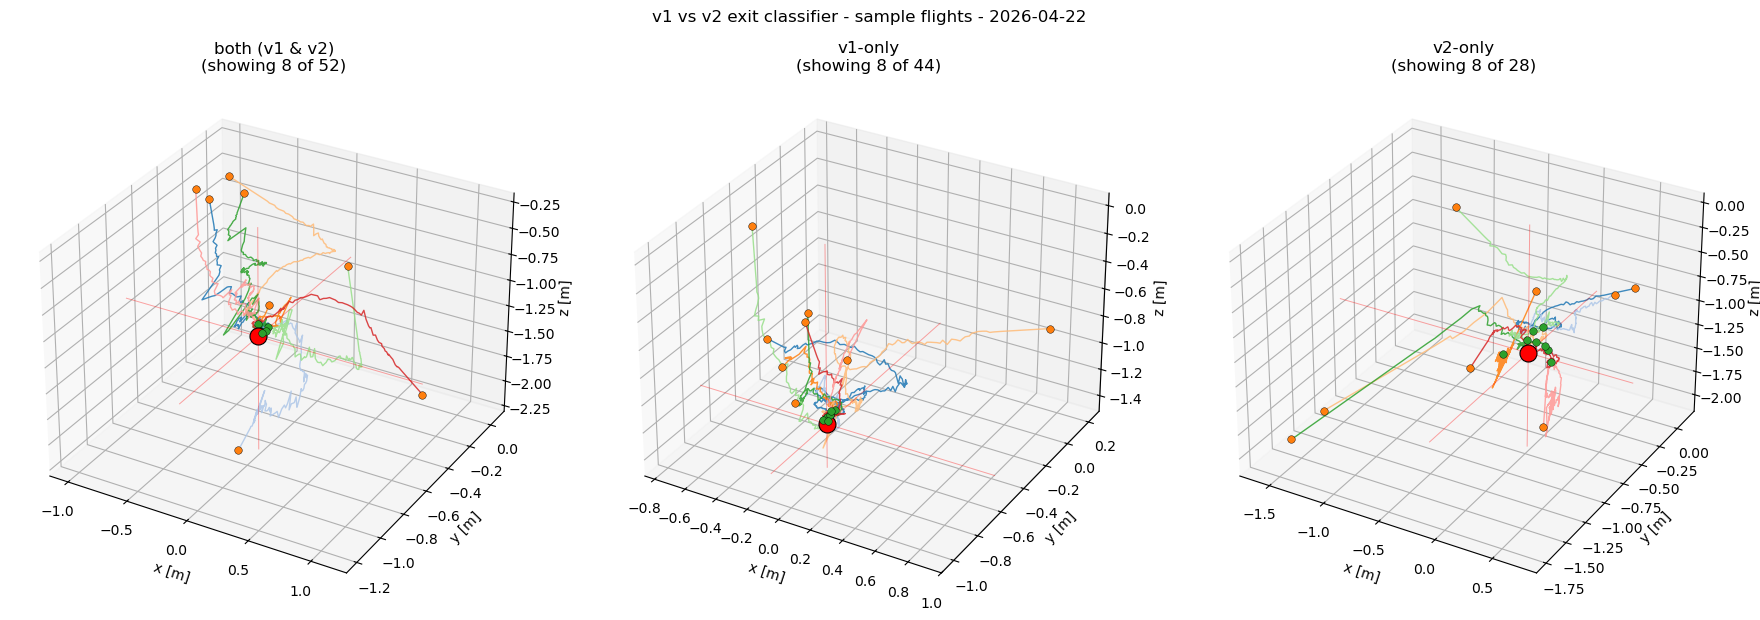

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -- Controls --------------------------------------------------------------
N_PER_BUCKET = 8        # tracks to plot per sub-plot
RANDOM_SEED  = 0        # same seed each run -> same sample; bump for fresh ones
PADDING      = 0.20     # m, slack around the plotted bounding box
CLIP_RADIUS  = 3.0      # m, drop points further than this from the hive
# -------------------------------------------------------------------------

# --- 1. Align v1 and v2 flags per uid. --------------------------------------
# exit_results has (uid, hive_exit); exit_results_v2 has (uid, hive_exit_v2).
# Outer merge keeps every uid from either frame; missing values fill to False
# so we can do boolean logic without NaN-handling surprises.
flags = (exit_results[["uid", "hive_exit"]]
         .merge(exit_results_v2[["uid", "hive_exit_v2"]],
                on="uid", how="outer"))
flags["hive_exit"]    = flags["hive_exit"].fillna(False).astype(bool)
flags["hive_exit_v2"] = flags["hive_exit_v2"].fillna(False).astype(bool)

# --- 2. Build the three buckets via boolean masks. --------------------------
# & = AND, | = OR, ~ = NOT. These are element-wise pandas Series operators.
buckets = {
    "both (v1 & v2)": flags[flags["hive_exit"] & flags["hive_exit_v2"]],
    "v1-only":        flags[flags["hive_exit"] & ~flags["hive_exit_v2"]],
    "v2-only":        flags[~flags["hive_exit"] & flags["hive_exit_v2"]],
}
for name, df in buckets.items():
    print(f"{name:16s}: {len(df):4d} tracks total")

# --- 3. Sample reproducibly from each bucket. -------------------------------
# df.sample(n, random_state=SEED) returns the same rows every time for the
# same seed - important so that "re-running the cell" doesn't shuffle things.
sampled = {}
for name, df in buckets.items():
    n = min(N_PER_BUCKET, len(df))
    sampled[name] = (df.sample(n=n, random_state=RANDOM_SEED)
                     if n > 0 else df.head(0))

# --- 4. Load flight_tracks once (no need to re-read per bucket). ------------
ft_cmp = pd.read_csv(EXPORT_DIR / "flight_tracks.csv")
if "pos_valid_insect" in ft_cmp.columns:
    ft_cmp = ft_cmp[ft_cmp["pos_valid_insect"] == 1]
# Pre-index by detection_uid for O(1) lookups instead of scanning the whole
# DataFrame for each track.
ft_by_uid = {uid: g for uid, g in ft_cmp.groupby("detection_uid")}

# --- 5. Decide which hive(s) to draw. --------------------------------------
if SPOT_SELECTION == "both":
    hives_to_show = [("hive 900", hive_900_pos),
                     ("hive 939", hive_939_pos)]
else:
    hives_to_show = [(f"hive {SPOT_SELECTION}", HIVE_POS)]
hive_arr = np.stack([h for _, h in hives_to_show])

# --- 6. Three 3D subplots side by side. ------------------------------------
# subplot_kw={"projection": "3d"} turns each axes into a 3D one. Without
# this you get 2D axes that can't do .plot(x, y, z).
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw=dict(projection="3d"))
cmap = plt.get_cmap("tab20")

def _draw_hive(ax, pos, label, xlim, ylim, zlim):
    """Hive cross-hair + big red dot. Drawn LAST (after tracks) so the dot
    isn\'t swallowed by matplotlib\'s unreliable 3D z-ordering."""
    ax.plot(xlim, [pos[1]]*2, [pos[2]]*2, c="red", lw=0.7, alpha=0.35)
    ax.plot([pos[0]]*2, ylim, [pos[2]]*2, c="red", lw=0.7, alpha=0.35)
    ax.plot([pos[0]]*2, [pos[1]]*2, zlim, c="red", lw=0.7, alpha=0.35)
    ax.scatter(pos[0], pos[1], pos[2], c="red", marker="o", s=150,
               edgecolors="black", linewidths=0.8, label=label,
               depthshade=False)

for ax, (bucket_name, sample_df) in zip(axes, sampled.items()):
    uids = sample_df["uid"].astype(int).tolist()
    plotted_pts = []

    for i, uid in enumerate(uids):
        trk = ft_by_uid.get(uid)
        if trk is None or trk.empty:
            continue
        xyz = trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(float)

        # Clip samples far from any hive so one glitch doesn\'t stretch
        # the bounding box and shrink the hive to a pixel.
        dists = np.min(np.linalg.norm(
            xyz[:, None, :] - hive_arr[None, :, :], axis=-1), axis=1)
        keep = dists <= CLIP_RADIUS
        plotted_pts.append(xyz[keep])

        color = cmap(i % 20)
        ax.plot(xyz[:, 0], xyz[:, 1], xyz[:, 2], color=color, lw=1.0, alpha=0.85)
        # Start = green, end = orange
        ax.scatter(xyz[0, 0], xyz[0, 1], xyz[0, 2],
                   color="tab:green", s=30,
                   edgecolors="black", linewidths=0.3)
        ax.scatter(xyz[-1, 0], xyz[-1, 1], xyz[-1, 2],
                   color="tab:orange", s=30,
                   edgecolors="black", linewidths=0.3)

    # --- 7. Fit the axes to what we just plotted (+ padding). --------------
    if plotted_pts:
        all_pts = np.vstack(plotted_pts + [hive_arr])
    else:
        all_pts = hive_arr
    lo = all_pts.min(axis=0) - PADDING
    hi = all_pts.max(axis=0) + PADDING
    xlim = (lo[0], hi[0]); ylim = (lo[1], hi[1]); zlim = (lo[2], hi[2])
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_zlim(zlim)

    # --- 8. Hive on top. ----------------------------------------------------
    for lbl, pos in hives_to_show:
        _draw_hive(ax, pos, lbl, xlim, ylim, zlim)

    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    ax.set_title(f"{bucket_name}\n(showing {len(uids)} of "
                 f"{len(buckets[bucket_name])})")

fig.suptitle(f"v1 vs v2 exit classifier - sample flights "
             f"- {TARGET_DATE.date()}", y=1.02)
plt.tight_layout()
plt.show()


### 6. Multi-day validation sweep (v1 / v2 / v3)

Runs all three classifiers across every `(date, system_id)` combination already on disk, directly from `cache/flight_data_<date>_system_<id>/`. No API calls, no re-fetch. Produces one row per (date, system) with:

- `n_tracks`, `n_returns`, `n_v1`, `n_v2`, `n_v3`
- `re_ratio` for each (target ~1.0)
- `median_trip_s` (trip-duration median using v3 exits)
- `night_count` (any exits/returns flagged between 22:00 and 05:00 - should be 0)

Two plots below the table: re_ratio trend across days, and per-day n_exits comparison. If a classifier is stable, its line should be flat-ish near 1.0. If it swings (e.g. 0.6 on Monday, 2.3 on Tuesday), something is drifting - camera calibration, tracker quality, or biological (but colony behaviour usually doesn't double in a day).


Sweeping cache: /Users/jaspe/Projects/Claude/Bumblebee-monitoring/src/flight_analysis/pats/cache

=== multi-day sweep ===

      date  system_id  n_tracks  n_returns  n_v1  n_v2  n_v3  re_ratio_v1  re_ratio_v2  re_ratio_v3  median_trip_s  n_matched  night_count
2026-04-19        900      1080        226   129    30   150     1.751938     7.533333     1.506667          928.5        150            0
2026-04-21        900        21          0     0     1     1          NaN     0.000000     0.000000            NaN          0            0
2026-04-21        939         0          0     0     0     0          NaN          NaN          NaN            NaN          0            0
2026-04-22        900       846        139    93    25   110     1.494624     5.560000     1.263636         2156.5        110            0
2026-04-22        939       659         91    74    26    87     1.229730     3.500000     1.045977         4117.0         86            0
2026-04-23        900         0          0 

/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1609027904.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["date"], rotation=30, ha="right")
/var/folders/qf/04n5tyxx79l0r05973_1fp9m0000gn/T/ipykernel_92659/1609027904.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["date"], rotation=30, ha="right")


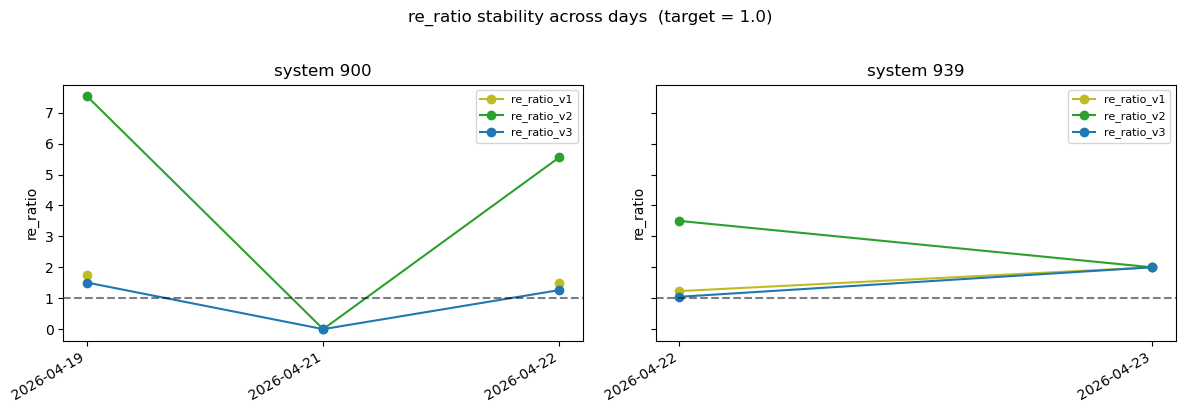

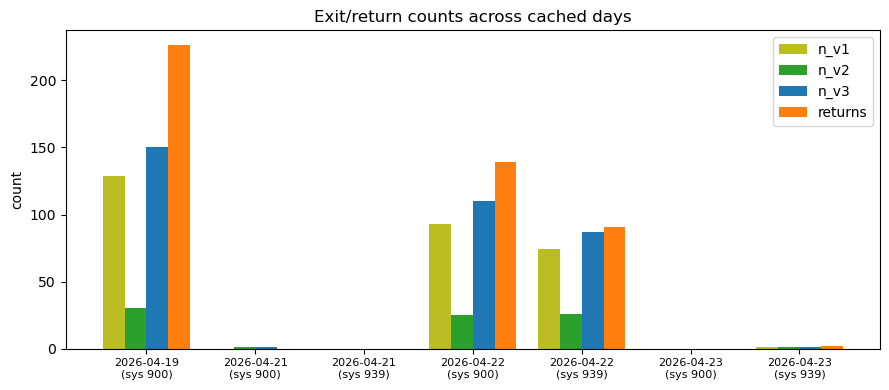

In [28]:
import matplotlib.pyplot as plt
import re
from pathlib import Path

# The cache lives next to the notebook. EXPORT_DIR already points at today's
# export folder, but for sweeping we want the root cache directory.
CACHE_BASE = Path("cache")
if not CACHE_BASE.exists():
    # Notebook might be run from a different cwd - fall back to the parent of
    # EXPORT_DIR.
    CACHE_BASE = EXPORT_DIR.parent
print(f"Sweeping cache: {CACHE_BASE.resolve()}")

# -- Self-contained classifier helpers (mirror the notebook's definitions) --
STRONG_NO = {"closest_in_future", "too_far", "too_much_lag"}
WEAK_NO   = {"slow", "short_track"}

def _valid_xyz(trk):
    if "pos_valid_insect" in trk.columns:
        trk = trk[trk["pos_valid_insect"] == 1]
    if len(trk) == 0:
        return None
    return trk[["posX_insect", "posY_insect", "posZ_insect"]].to_numpy(dtype=float)

def _is_return(xyz, hive, tol, tail=10):
    if xyz is None or len(xyz) == 0:
        return False, np.nan
    tail_xyz = xyz[-tail:]
    d = np.min(np.linalg.norm(tail_xyz - hive, axis=1))
    return bool(d <= tol), float(d)

def _is_exit_v1(xyz, hive, tol):
    if xyz is None or len(xyz) == 0:
        return False, np.nan
    d = float(np.linalg.norm(xyz[0] - hive))
    return bool(d <= tol), d

def _is_exit_v2(xyz, hive, head_n=5, exit_tol=0.20,
                min_speed=0.5, max_lag_s=2.0, fps=60.0):
    if xyz is None or len(xyz) < head_n:
        return False, "short_track"
    head = xyz[:head_n]
    p0 = head[0]
    t = np.arange(head_n) / fps
    v = np.array([np.polyfit(t, head[:, k], 1)[0] for k in range(3)])
    speed = float(np.linalg.norm(v))
    if speed < min_speed:
        return False, "slow"
    rel = p0 - hive
    t_star = -float(np.dot(v, rel)) / (speed ** 2)
    if t_star > 0:
        return False, "closest_in_future"
    if abs(t_star) > max_lag_s:
        return False, "too_much_lag"
    d_min = float(np.linalg.norm(p0 + v * t_star - hive))
    return (d_min <= exit_tol, "ok" if d_min <= exit_tol else "too_far")

# -- Sweep loop ------------------------------------------------------------
pat = re.compile(r"flight_data_(\d{4}-\d{2}-\d{2})_system_(\d+)$")

rows = []
for d in sorted(CACHE_BASE.glob("flight_data_*_system_*")):
    m = pat.match(d.name)
    if not m:
        continue
    date_str, sys_str = m.groups()
    sys_id = int(sys_str)
    if sys_id not in HIVE_BY_SYSTEM:
        continue

    det_csv    = d / "detections.csv"
    tracks_dir = d / "tracks"
    if not det_csv.exists() or not tracks_dir.exists():
        continue

    dets = pd.read_csv(det_csv)
    dets["ts"] = pd.to_datetime(dets["datetime"],
                                format="%Y%m%d_%H%M%S", errors="coerce")

    hive = np.asarray(HIVE_BY_SYSTEM[sys_id])

    n_tracks = n_ret = n_v1 = n_v2 = n_v3 = 0
    exit_ts_v3 = []   # for trip-duration + night count
    return_ts  = []

    for _, det in dets.iterrows():
        uid = int(det["uid"])
        trk_path = tracks_dir / f"{uid}.csv"
        if not trk_path.exists():
            continue
        trk = pd.read_csv(trk_path)
        xyz = _valid_xyz(trk)
        if xyz is None or len(xyz) == 0:
            continue
        n_tracks += 1

        is_ret, _  = _is_return(xyz, hive, TOL)
        is_v1, _   = _is_exit_v1(xyz, hive, TOL)
        is_v2, rsn = _is_exit_v2(xyz, hive)
        is_v3 = is_v2 or (is_v1 and rsn in (WEAK_NO | {"no_v2"}))

        if is_ret:
            n_ret += 1
            return_ts.append(det["ts"])
        if is_v1: n_v1 += 1
        if is_v2: n_v2 += 1
        if is_v3:
            n_v3 += 1
            exit_ts_v3.append(det["ts"])

    # Trip duration (greedy) with v3 exits.
    ex_sorted = sorted(t for t in exit_ts_v3 if pd.notna(t))
    rt_sorted = sorted(t for t in return_ts  if pd.notna(t))
    used, trips = [False]*len(rt_sorted), []
    for et in ex_sorted:
        for j, rt in enumerate(rt_sorted):
            if used[j] or rt <= et:
                continue
            trips.append((rt - et).total_seconds())
            used[j] = True
            break
    median_trip = float(np.median(trips)) if trips else np.nan

    # Night-time activity (22:00 - 05:00 Amsterdam).
    def _is_night(ts):
        h = ts.hour
        return (h >= 22) or (h < 5)
    night = sum(1 for t in (exit_ts_v3 + return_ts)
                if pd.notna(t) and _is_night(t))

    rows.append({
        "date":          date_str,
        "system_id":     sys_id,
        "n_tracks":      n_tracks,
        "n_returns":     n_ret,
        "n_v1":          n_v1,
        "n_v2":          n_v2,
        "n_v3":          n_v3,
        "re_ratio_v1":   (n_ret / n_v1) if n_v1 else np.nan,
        "re_ratio_v2":   (n_ret / n_v2) if n_v2 else np.nan,
        "re_ratio_v3":   (n_ret / n_v3) if n_v3 else np.nan,
        "median_trip_s": median_trip,
        "n_matched":     len(trips),
        "night_count":   night,
    })

sweep_df = pd.DataFrame(rows).sort_values(["date", "system_id"]).reset_index(drop=True)
print("\n=== multi-day sweep ===\n")
print(sweep_df.to_string(index=False))

# -- Plots -----------------------------------------------------------------
if not sweep_df.empty:
    # (a) re_ratio trend, one line per classifier, faceted by system
    systems = sorted(sweep_df["system_id"].unique())
    fig, axes = plt.subplots(1, len(systems), figsize=(6 * len(systems), 4),
                              sharey=True, squeeze=False)
    for ax, sid in zip(axes[0], systems):
        sub = sweep_df[sweep_df["system_id"] == sid]
        for col, color in [("re_ratio_v1", "tab:olive"),
                           ("re_ratio_v2", "tab:green"),
                           ("re_ratio_v3", "tab:blue")]:
            ax.plot(sub["date"], sub[col], "o-", color=color, label=col)
        ax.axhline(1.0, color="black", ls="--", alpha=0.5)
        ax.set_xticklabels(sub["date"], rotation=30, ha="right")
        ax.set_title(f"system {sid}")
        ax.set_ylabel("re_ratio")
        ax.legend(fontsize=8)
    fig.suptitle("re_ratio stability across days  (target = 1.0)", y=1.02)
    plt.tight_layout()
    plt.show()

    # (b) absolute counts side-by-side
    fig, ax = plt.subplots(figsize=(max(9, len(sweep_df) * 0.8), 4))
    x = np.arange(len(sweep_df)); w = 0.2
    ax.bar(x - 1.5*w, sweep_df["n_v1"],      width=w, color="tab:olive",  label="n_v1")
    ax.bar(x - 0.5*w, sweep_df["n_v2"],      width=w, color="tab:green",  label="n_v2")
    ax.bar(x + 0.5*w, sweep_df["n_v3"],      width=w, color="tab:blue",   label="n_v3")
    ax.bar(x + 1.5*w, sweep_df["n_returns"], width=w, color="tab:orange", label="returns")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r.date}\n(sys {r.system_id})" for r in sweep_df.itertuples()],
        rotation=0, fontsize=8)
    ax.set_ylabel("count")
    ax.set_title("Exit/return counts across cached days")
    ax.legend()
    plt.tight_layout()
    plt.show()
